# Q Learning RTOS Visualizations: "Exclusive Fairness" Reward
### Braden Everson

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
logs = pd.read_csv("../data/rtos/2_cpu_1min_50max_exclusive_fairness.csv")

In [3]:
logs.head()

,task_id,timestamp_us,total_run_time,total_io_wait_time,total_ready_wait_time,delta
0,F,98995,40874,0,39008,9
1,B,108995,38992,0,50890,10
2,F,193995,90864,0,84018,9
3,F,288995,140854,0,129028,9
4,B,317995,137970,0,160912,10


In [4]:
logs["pct_waiting"] = logs["total_ready_wait_time"] / logs["timestamp_us"]

## Exclusive Fairness Reward Function:

### $$R = t_{cpu} - (\alpha * t_{ready\_wait}) + t_{io\_wait} - (\beta*(t_{avg\_ex\_wait} - \frac{1}{N}))$$


We will test this model versus a baseline of always allocating 10ms time quantums in a variety of different process configurations

### Scenario 1: 2 Exclusively CPU Intensive Processes

Text(0.5, 0, 'Timestamp')

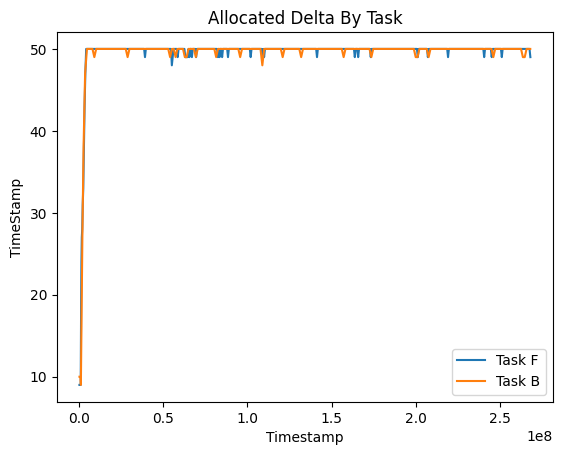

In [5]:
F = logs[logs["task_id"] == 'F']
B = logs[logs["task_id"] == 'B']

plt.plot(F["timestamp_us"], F["delta"], label="Task F")
plt.plot(B["timestamp_us"], B["delta"], label="Task B")

plt.title("Allocated Delta By Task")

plt.legend()

plt.ylabel("TimeStamp")
plt.xlabel("Timestamp")

Text(0.5, 0, 'Timestamp')

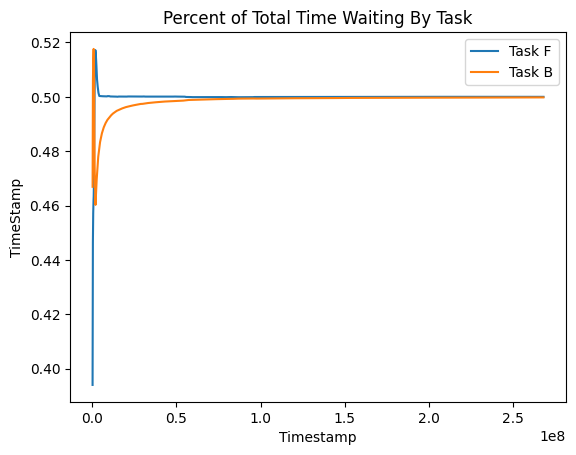

In [6]:
F = logs[logs["task_id"] == 'F']
B = logs[logs["task_id"] == 'B']

plt.plot(F["timestamp_us"], F["pct_waiting"], label="Task F")
plt.plot(B["timestamp_us"], B["pct_waiting"], label="Task B")

plt.title("Percent of Total Time Waiting By Task")

plt.legend()

plt.ylabel("TimeStamp")
plt.xlabel("Timestamp")

This isn't unique to the Q Learning method. A baseline scheduler that always allocates any delta `N` would expect 50% wait time for both tasks in a two cpu-heavy task environment. Where the agent has optimized in this case is in limiting the number of OS calls by maxing out the delta for both tasks to 50 very quickly.